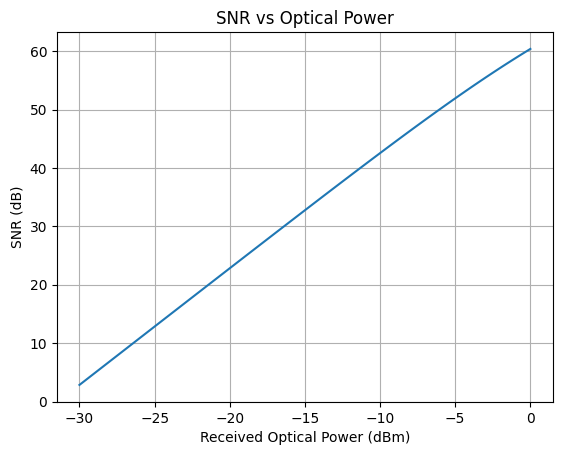

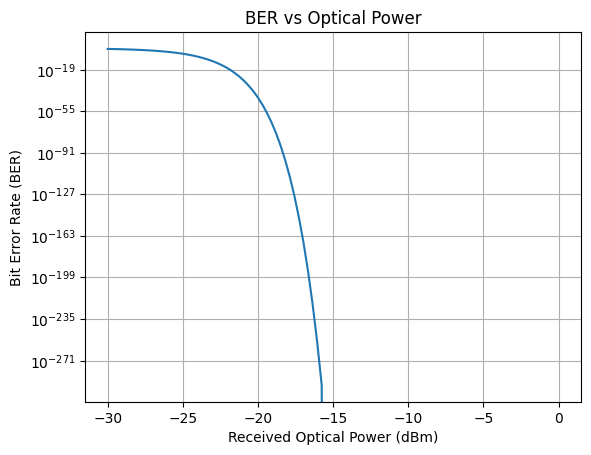

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.special import erfc

# Constants
q = 1.6e-19      # Electron charge
k = 1.38e-23     # Boltzmann constant
T = 300          # Temperature (K)
B = 1e9          # Bandwidth (Hz)
RL = 50          # Load resistance (Ohm)

# Optical power range in dBm
P_dBm = np.linspace(-30, 0, 100)
P_watt = 1e-3 * 10**(P_dBm / 10)

# Responsivity
R = 0.8  # A/W

# Photocurrent
Ip = R * P_watt

# Noise calculations
shot_noise = 2 * q * Ip * B
thermal_noise = (4 * k * T * B) / RL

# Total noise
total_noise = shot_noise + thermal_noise

# SNR
SNR = (Ip**2) / total_noise

# BER
BER = 0.5 * erfc(np.sqrt(SNR / 2))

# Plot SNR
plt.figure()
plt.plot(P_dBm, 10 * np.log10(SNR))
plt.xlabel("Received Optical Power (dBm)")
plt.ylabel("SNR (dB)")
plt.title("SNR vs Optical Power")
plt.grid()
plt.show()

# Plot BER
plt.figure()
plt.semilogy(P_dBm, BER)
plt.xlabel("Received Optical Power (dBm)")
plt.ylabel("Bit Error Rate (BER)")
plt.title("BER vs Optical Power")
plt.grid()
plt.show()

Original Data (User 1): [0 1 1 0 1 1 1 1 1 1]
Decoded Data (User 1): [1 1 1 0 1 1 1 1 1 1]
Bit Error Rate (BER): 0.1


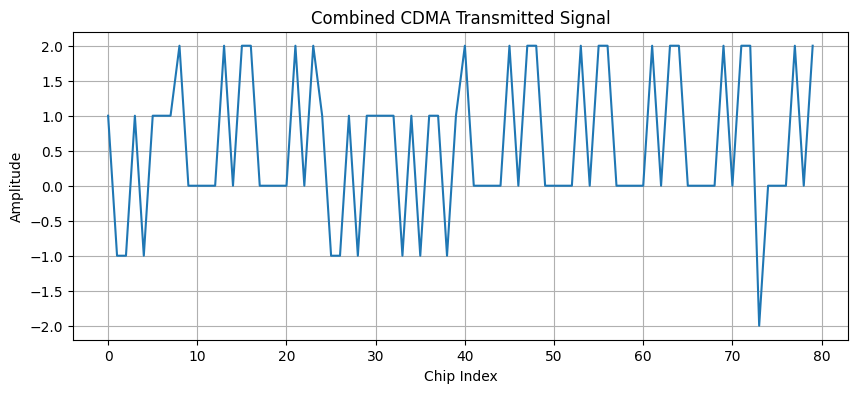

In [2]:
import numpy as np
import matplotlib.pyplot as plt

# Parameters
num_users = 3
data_length = 10
code_length = 8
noise_variance = 0.5

np.random.seed(0)

# Generate random binary data for each user
data = np.random.randint(0, 2, (num_users, data_length))

# Generate random spreading codes (+1, -1)
codes = np.random.choice([-1, 1], (num_users, code_length))

# Spreading process
spread_signals = []

for i in range(num_users):
    user_signal = []
    for bit in data[i]:
        spread_bit = bit * codes[i]
        user_signal.extend(spread_bit)
    spread_signals.append(user_signal)

spread_signals = np.array(spread_signals)

# Combine all users
transmitted_signal = np.sum(spread_signals, axis=0)

# Add Gaussian noise
noise = np.random.normal(0, np.sqrt(noise_variance), transmitted_signal.shape)
received_signal = transmitted_signal + noise

# Receiver (Decode user 1)
user_index = 0
decoded_bits = []

for i in range(data_length):
    segment = received_signal[i * code_length:(i + 1) * code_length]
    correlation = np.sum(segment * codes[user_index])
    decoded_bit = 1 if correlation > 0 else 0
    decoded_bits.append(decoded_bit)

decoded_bits = np.array(decoded_bits)

# BER Calculation
errors = np.sum(data[user_index] != decoded_bits)
BER = errors / data_length

print("Original Data (User 1):", data[user_index])
print("Decoded Data (User 1):", decoded_bits)
print("Bit Error Rate (BER):", BER)

# Plot transmitted signal
plt.figure(figsize=(10, 4))
plt.plot(transmitted_signal[:200])
plt.title("Combined CDMA Transmitted Signal")
plt.xlabel("Chip Index")
plt.ylabel("Amplitude")
plt.grid()
plt.show()

In [3]:
import pandas as pd
import re
import string
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression

# Step 1: Create sample dataset
data = {
    "tweet": [
        "I hate you",
        "This is a wonderful day",
        "You are disgusting",
        "I love my country",
        "They should be kicked out",
        "Have a nice evening",
        "You are stupid",
        "Peace and love for all"
    ],
    "label": [1, 0, 1, 0, 1, 0, 1, 0]  # 1 = Hate, 0 = Non-Hate
}

df = pd.DataFrame(data)

# Step 2: Text preprocessing
def clean_text(text):
    text = text.lower()
    text = re.sub(r'\d+', '', text)
    text = re.sub(r'[%s]' % string.punctuation, '', text)
    return text

df['tweet'] = df['tweet'].apply(clean_text)

# Step 3: Feature extraction
X = df['tweet']
y = df['label']

vectorizer = TfidfVectorizer(stop_words='english')
X = vectorizer.fit_transform(X)

# Step 4: Train model
model = LogisticRegression(class_weight='balanced')
model.fit(X, y)

# Step 5: Prediction function
def predict_tweet(tweet):
    tweet = clean_text(tweet)
    tweet_vector = vectorizer.transform([tweet])
    prediction = model.predict(tweet_vector)
    return "Hate Tweet" if prediction[0] == 1 else "Non-Hate Tweet"

# Step 6: Test the system
print(predict_tweet("I hate this group"))
print(predict_tweet("Have a good day"))

Hate Tweet
Non-Hate Tweet


In [5]:
import nltk

nltk.download('punkt')
nltk.download('stopwords')
nltk.download('averaged_perceptron_tagger')

from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize, sent_tokenize

# Sample passage
passage = "The sun shone brightly in the clear blue sky as birds chirped happily in the trees. The sound of a distant river flowing gently could be heard in the background. A gentle breeze rustled through the leaves, creating a soothing melody. It was a perfect day for a leisurely stroll through the countryside."

# Sentence tokenization
words = sent_tokenize(passage)

# Stopwords
stop_word = set(stopwords.words('english'))

for i in words:
    # Word tokenization
    tokenized_words = word_tokenize(i)
    
    # Remove stopwords
    filtered_words = [word for word in tokenized_words if word.lower() not in stop_word]
    
    # POS tagging
    pos_tagged = nltk.pos_tag(filtered_words)
    
    print(pos_tagged)

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\Vedant\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping tokenizers\punkt.zip.
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\Vedant\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping corpora\stopwords.zip.
[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     C:\Users\Vedant\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping taggers\averaged_perceptron_tagger.zip.


LookupError: 
**********************************************************************
  Resource 'punkt_tab' not found.
  Please use the NLTK Downloader to obtain the resource:

  >>> import nltk
  >>> nltk.download('punkt_tab')

  For more information see: https://www.nltk.org/data.html

  Attempted to load 'tokenizers/punkt_tab/english/'

  Searched in:
    - 'C:\\Users\\Vedant/nltk_data'
    - 'c:\\Users\\Vedant\\AppData\\Local\\Programs\\Python\\Python311\\nltk_data'
    - 'c:\\Users\\Vedant\\AppData\\Local\\Programs\\Python\\Python311\\share\\nltk_data'
    - 'c:\\Users\\Vedant\\AppData\\Local\\Programs\\Python\\Python311\\lib\\nltk_data'
    - 'C:\\Users\\Vedant\\AppData\\Roaming\\nltk_data'
    - 'C:\\nltk_data'
    - 'D:\\nltk_data'
    - 'E:\\nltk_data'
**********************************************************************


In [8]:
import nltk

# Download required resources (run once)
nltk.download('punkt_tab')
nltk.download('averaged_perceptron_tagger_eng')

# Given sentence
sentence = "The sun shone brightly in the clear blue sky as birds chirped happily in the trees. The sound of a distant river flowing gently could be heard in the background. A gentle breeze rustled through the leaves, creating a soothing melody. It was a perfect day for a leisurely stroll through the countryside."

# Tokenize sentence into words
words = nltk.word_tokenize(sentence)

# Perform POS tagging
pos_tags = nltk.pos_tag(words)

# Print result
print(pos_tags)

[('The', 'DT'), ('sun', 'NN'), ('shone', 'NN'), ('brightly', 'RB'), ('in', 'IN'), ('the', 'DT'), ('clear', 'JJ'), ('blue', 'JJ'), ('sky', 'NN'), ('as', 'IN'), ('birds', 'NNS'), ('chirped', 'VBD'), ('happily', 'RB'), ('in', 'IN'), ('the', 'DT'), ('trees', 'NNS'), ('.', '.'), ('The', 'DT'), ('sound', 'NN'), ('of', 'IN'), ('a', 'DT'), ('distant', 'JJ'), ('river', 'NN'), ('flowing', 'VBG'), ('gently', 'RB'), ('could', 'MD'), ('be', 'VB'), ('heard', 'VBN'), ('in', 'IN'), ('the', 'DT'), ('background', 'NN'), ('.', '.'), ('A', 'DT'), ('gentle', 'JJ'), ('breeze', 'NN'), ('rustled', 'VBD'), ('through', 'IN'), ('the', 'DT'), ('leaves', 'NNS'), (',', ','), ('creating', 'VBG'), ('a', 'DT'), ('soothing', 'JJ'), ('melody', 'NN'), ('.', '.'), ('It', 'PRP'), ('was', 'VBD'), ('a', 'DT'), ('perfect', 'JJ'), ('day', 'NN'), ('for', 'IN'), ('a', 'DT'), ('leisurely', 'JJ'), ('stroll', 'NN'), ('through', 'IN'), ('the', 'DT'), ('countryside', 'NN'), ('.', '.')]


[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\Vedant\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package averaged_perceptron_tagger_eng to
[nltk_data]     C:\Users\Vedant\AppData\Roaming\nltk_data...
[nltk_data]   Package averaged_perceptron_tagger_eng is already up-to-
[nltk_data]       date!


In [1]:
import nltk
from nltk.corpus import movie_reviews
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, classification_report

# Download required NLTK data
nltk.download('movie_reviews')
nltk.download('stopwords')
nltk.download('wordnet')

# Initialize tools
stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

# Preprocessing function
def preprocess_text(words):
    cleaned_words = []
    for word in words:
        word = word.lower()
        if word.isalpha() and word not in stop_words:
            cleaned_words.append(lemmatizer.lemmatize(word))
    return " ".join(cleaned_words)

# Prepare dataset
documents = []
labels = []

for category in movie_reviews.categories():
    for fileid in movie_reviews.fileids(category):
        words = movie_reviews.words(fileid)
        processed_text = preprocess_text(words)
        documents.append(processed_text)
        labels.append(category)

# Split dataset
X_train, X_test, y_train, y_test = train_test_split(
    documents, labels, test_size=0.2, random_state=42
)

# TF-IDF feature extraction
vectorizer = TfidfVectorizer(max_features=2000)
X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf = vectorizer.transform(X_test)

# Train Naive Bayes classifier
classifier = MultinomialNB()
classifier.fit(X_train_tfidf, y_train)

# Evaluate model
y_pred = classifier.predict(X_test_tfidf)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

# Test with custom sentence
example_sentence = "This movie is great and very entertaining"
example_tfidf = vectorizer.transform([example_sentence])

prediction = classifier.predict(example_tfidf)

print("\nSentence:", example_sentence)
print("Predicted Category:", prediction[0])

[nltk_data] Downloading package movie_reviews to
[nltk_data]     C:\Users\Vedant\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping corpora\movie_reviews.zip.
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\Vedant\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\Vedant\AppData\Roaming\nltk_data...


Accuracy: 0.7925

Classification Report:
               precision    recall  f1-score   support

         neg       0.77      0.82      0.80       199
         pos       0.81      0.76      0.79       201

    accuracy                           0.79       400
   macro avg       0.79      0.79      0.79       400
weighted avg       0.79      0.79      0.79       400


Sentence: This movie is great and very entertaining
Predicted Category: pos


In [2]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# -------------------------------
# Step 1: Create sample HR dataset
# -------------------------------
data = {
    "Age": [25, 45, 30, 40, 28, 50, 35, 29],
    "MonthlyIncome": [30000, 70000, 40000, 65000, 35000, 80000, 55000, 32000],
    "JobSatisfaction": [1, 4, 2, 3, 2, 4, 3, 1],
    "YearsAtCompany": [1, 10, 3, 8, 2, 15, 6, 1],
    "OverTime": ["Yes", "No", "Yes", "No", "Yes", "No", "No", "Yes"],
    "Attrition": ["Yes", "No", "Yes", "No", "Yes", "No", "No", "Yes"]
}

df = pd.DataFrame(data)
print(df)

# -------------------------------
# Step 2: Encode categorical data
# -------------------------------
encoder = LabelEncoder()

df["OverTime"] = encoder.fit_transform(df["OverTime"])
df["Attrition"] = encoder.fit_transform(df["Attrition"])  # Yes=1, No=0

# -------------------------------
# Step 3: Feature selection
# -------------------------------
X = df.drop("Attrition", axis=1)
y = df["Attrition"]

# -------------------------------
# Step 4: Train-test split
# -------------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42
)

# -------------------------------
# Step 5: Train Random Forest model
# -------------------------------
model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

model.fit(X_train, y_train)

# -------------------------------
# Step 6: Model evaluation
# -------------------------------
y_pred = model.predict(X_test)

print("\nAccuracy:", accuracy_score(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

# -------------------------------
# Step 7: Predict new employee attrition
# -------------------------------
new_employee = pd.DataFrame({
    "Age": [32],
    "MonthlyIncome": [45000],
    "JobSatisfaction": [2],
    "YearsAtCompany": [3],
    "OverTime": [1]   # 1 = Yes, 0 = No
})

prediction = model.predict(new_employee)

if prediction[0] == 1:
    print("\nPrediction: Employee is likely to leave (Attrition = Yes)")
else:
    print("\nPrediction: Employee is likely to stay (Attrition = No)")

   Age  MonthlyIncome  JobSatisfaction  YearsAtCompany OverTime Attrition
0   25          30000                1               1      Yes       Yes
1   45          70000                4              10       No        No
2   30          40000                2               3      Yes       Yes
3   40          65000                3               8       No        No
4   28          35000                2               2      Yes       Yes
5   50          80000                4              15       No        No
6   35          55000                3               6       No        No
7   29          32000                1               1      Yes       Yes

Accuracy: 1.0

Confusion Matrix:
 [[2]]

Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00         2

    accuracy                           1.00         2
   macro avg       1.00      1.00      1.00         2
weighted avg       1.00      1.00      1.00       

c:\Users\Vedant\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\metrics\_classification.py:620: UserWarning: A single label was found in 'y_true' and 'y_pred'. For the confusion matrix to have the correct shape, use the 'labels' parameter to pass all known labels.
  warnings.warn(
